In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [44]:
df = pd.read_csv('../data/raw/dataset.csv')
print(df.shape)
df.head()

(975, 30)


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,...,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,...,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


In [45]:
df['datetime'] = pd.to_datetime(df['datetime'],dayfirst=True)

option_cols = [c for c in df.columns if c not in ['datetime','underlying_price']]
ce_cols = [c for c in option_cols if c.endswith('CE')]
pe_cols = [c for c in option_cols if c.endswith('PE')]

### 1. Transforming dataset to long format

In [46]:
# for CE options

df_ce = df.melt(
    id_vars=['datetime','underlying_price'],
    value_vars=ce_cols,
    var_name='contract',
    value_name='iv'
)

df_ce['option_type'] = 'CE'

df_ce['strike'] = df_ce['contract'].str[12:-2].astype(int)

df_pe = df.melt(
    id_vars = ['datetime','underlying_price'],
    value_vars=ce_cols,
    var_name='contract',
    value_name='iv'
)

df_pe['option_type'] = 'PE'

df_pe['strike'] = df_pe['contract'].str[12:-2].astype(int)

df_long = pd.concat([df_ce,df_pe],ignore_index=True)

df_long = (
    df_long.sort_values(['datetime','option_type','strike']).reset_index(drop=True)
)

print(df_long.shape)
print(df_long['iv'].isna().sum())
df_long.head(5)

(27300, 6)
5382


,datetime,underlying_price,contract,iv,option_type,strike
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625200CE,0.12662,CE,25200
1,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625300CE,0.12330,CE,25300
2,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625400CE,0.11741,CE,25400
3,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625500CE,NaN,CE,25500
4,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625600CE,0.11005,CE,25600


### 2. Creating time features

In [47]:
df_long['hour'] = df_long['datetime'].dt.hour
df_long['minute'] = df_long['datetime'].dt.minute
df_long['day_of_week'] = df_long['datetime'].dt.dayofweek
df_long['date'] = df_long['datetime'].dt.date

session_start_min = df_long.iloc[0]['hour']*60 + df_long.iloc[0]['minute']
session_end_min = df_long.iloc[-1]['hour']*60 + df_long.iloc[-1]['minute']

df_long['session_progress'] = (df_long['hour']*600 + df_long['minute'] - session_start_min)/(session_end_min - session_start_min).clip(0,1)

df_long['days_to_expiry'] = ((df_long.iloc[-1]['datetime'] - df_long['datetime']).dt.total_seconds()/(60*60*24)).clip(lower=0).round(4)

print(df_long.shape)
df_long.sample(5)

(27300, 12)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry
2693,2026-01-08 11:00:00,26016.40,NIFTY27JAN2625700CE,0.10269,CE,25700,11,0,3,2026-01-08,6045.0,19.1840
6338,2026-01-12 09:20:00,25594.15,NIFTY27JAN2626200CE,0.10912,CE,26200,9,20,0,2026-01-12,4865.0,15.2535
8919,2026-01-13 10:45:00,25763.45,NIFTY27JAN2625300CE,0.11857,PE,25300,10,45,1,2026-01-13,5490.0,14.1944
5469,2026-01-09 13:00:00,25694.00,NIFTY27JAN2626100CE,0.09577,CE,26100,13,0,4,2026-01-09,7245.0,18.1007
1654,2026-01-07 14:10:00,26100.95,NIFTY27JAN2625400CE,0.11166,CE,25400,14,10,2,2026-01-07,7855.0,20.0521


### 3. Creating moneyness, dist. from atm, flag ce features

In [48]:
df_long['moneyness'] = df_long['strike']/df_long['underlying_price']
df_long['log_moneyness'] = np.log(df_long['moneyness'])

df_long['dist_from_atm'] = np.abs(df_long['strike']-df_long['underlying_price'])
df_long['dist_from_atm_pct'] = df_long['dist_from_atm']/df_long['underlying_price']

df_long['is_ce'] = (df_long['option_type'] == 'CE').astype(int)

print(df_long.shape)
df_long.sample(5)

(27300, 17)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce
6689,2026-01-12 10:20:00,25583.30,NIFTY27JAN2626300CE,0.11101,PE,26300,10,20,0,2026-01-12,5465.0,15.2118,1.028014,0.027629,716.70,0.028014,0
7172,2026-01-12 11:50:00,25491.70,NIFTY27JAN2625600CE,NaN,CE,25600,11,50,0,2026-01-12,6095.0,15.1493,1.004248,0.004239,108.30,0.004248,1
19763,2026-01-21 11:45:00,25045.15,NIFTY27JAN2626100CE,0.16362,PE,26100,11,45,2,2026-01-21,6090.0,6.1528,1.042118,0.041255,1054.85,0.042118,0
3486,2026-01-08 13:20:00,25914.55,NIFTY27JAN2625200CE,0.14112,PE,25200,13,20,3,2026-01-08,7265.0,19.0868,0.972427,-0.027961,714.55,0.027573,0
23752,2026-01-23 11:10:00,25281.60,NIFTY27JAN2626000CE,0.12821,CE,26000,11,10,4,2026-01-23,6055.0,4.1771,1.028416,0.028020,718.40,0.028416,1


### 4. Creating strike rank feature: unlike moneyness it is static feature which can help in edge detection

In [49]:
for otype in ['CE','PE']:
    mask = (df_long['option_type'] == otype)
    strikes_sorted = sorted(df_long.loc[mask,'strike'].unique())
    rank_map = {s:i/(len(strikes_sorted)-1) for i,s in enumerate(strikes_sorted)}
    df_long.loc[mask,'strike_rank'] = df_long.loc[mask,'strike'].map(rank_map)

print(df_long.shape)
df_long.sample(5)

(27300, 18)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank
5841,2026-01-09 14:05:00,25678.55,NIFTY27JAN2625500CE,0.10995,PE,25500,14,5,4,2026-01-09,7850.0,18.0556,0.993047,-0.006978,178.55,0.006953,0,0.230769
26769,2026-01-27 13:55:00,25040.65,NIFTY27JAN2625300CE,0.43769,CE,25300,13,55,1,2026-01-27,7300.0,0.0625,1.010357,0.010304,259.35,0.010357,1,0.076923
10508,2026-01-14 09:15:00,25671.90,NIFTY27JAN2626000CE,0.10139,CE,26000,9,15,2,2026-01-14,4860.0,13.2569,1.012781,0.012700,328.10,0.012781,1,0.615385
21421,2026-01-22 10:30:00,25273.25,NIFTY27JAN2625300CE,0.13166,CE,25300,10,30,3,2026-01-22,5475.0,5.2049,1.001058,0.001058,26.75,0.001058,1,0.076923
19439,2026-01-21 10:50:00,25009.05,NIFTY27JAN2625900CE,NaN,CE,25900,10,50,2,2026-01-21,5495.0,6.1910,1.035625,0.035005,890.95,0.035625,1,0.538462


### 5. Creating neighbour IV feature: curve for IV at same timestamp and varying strikes shows smooth behaviour suggesting strong predicting capability of neighboring strikes

In [50]:
df_long = df_long.sort_values(['datetime','option_type','strike']).reset_index(drop=True)

for shift_val in [-2,-1,1,2]:
    col = f"iv_neighbor_{shift_val:+d}"
    df_long[col] = df_long.groupby(['datetime','option_type'])['iv'].shift(-shift_val)

df_long['iv_neighbor_mean'] = df_long[['iv_neighbor_+1','iv_neighbor_-1']].mean(axis=1)
df_long['wide_iv_neighbor_mean'] = df_long[['iv_neighbor_+2','iv_neighbor_-2']].mean(axis=1)

print(df_long.shape)
df_long.sample(5)

(27300, 24)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,...,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean
11122,2026-01-14 11:05:00,25733.00,NIFTY27JAN2625800CE,0.09724,CE,25800,11,5,2,2026-01-14,...,67.00,0.002604,1,0.461538,0.10013,0.09901,0.09648,NaN,0.097745,0.100130
14658,2026-01-16 15:20:00,25695.90,NIFTY27JAN2625200CE,0.12636,PE,25200,15,20,4,2026-01-16,...,495.90,0.019299,0,0.000000,NaN,NaN,0.11841,0.11262,0.118410,0.112620
387,2026-01-07 10:20:00,26169.15,NIFTY27JAN2626100CE,NaN,PE,26100,10,20,2,2026-01-07,...,69.15,0.002642,0,0.692308,0.09399,0.09285,0.08918,0.08778,0.091015,0.090885
21841,2026-01-22 11:45:00,25200.80,NIFTY27JAN2625300CE,0.12707,CE,25300,11,45,3,2026-01-22,...,99.20,0.003936,1,0.076923,NaN,0.13034,0.12579,0.12618,0.128065,0.126180
24768,2026-01-23 14:10:00,25058.25,NIFTY27JAN2625400CE,0.11716,PE,25400,14,10,4,2026-01-23,...,341.75,0.013638,0,0.153846,0.11362,0.11404,0.12150,0.12778,0.117770,0.120700


### 6. Lag and rolling feature: curve for a particular strike's IV vs time is also smooth for a trading day suggesting high dependency of a particular IV on previous IVs


In [52]:
df_long = df_long.sort_values(['option_type','strike','datetime']).reset_index(drop=True)

df_long['iv_lag_1'] = df_long.groupby(['option_type','strike'])['iv'].shift(1)

df_long['iv_roll_mean_5'] = df_long.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,min_periods=2).mean()
)

df_long['iv_roll_std_5'] = df_long.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,min_periods=2).std()
)

df_long['iv_roll_mean_10'] = df_long.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(10,min_periods=3).mean()
)

print(df_long.shape)
df_long.sample(5)

(27300, 28)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,...,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean,iv_lag_1,iv_roll_mean_5,iv_roll_std_5,iv_roll_mean_10
11118,2026-01-14 10:45:00,25665.90,NIFTY27JAN2626300CE,0.10481,CE,26300,10,45,2,2026-01-14,...,0.10173,0.10276,0.10705,0.11056,0.104905,0.106145,NaN,0.101827,0.000651,0.100553
14337,2026-01-21 10:15:00,25145.80,NIFTY27JAN2625200CE,0.12333,PE,25200,10,15,2,2026-01-21,...,NaN,NaN,0.11947,0.11750,0.119470,0.117500,0.12749,0.122275,0.006037,0.123030
1379,2026-01-14 11:40:00,25766.75,NIFTY27JAN2625300CE,0.11197,CE,25300,11,40,2,2026-01-14,...,NaN,0.11206,0.10283,NaN,0.107445,NaN,0.11474,0.123453,0.011100,0.118836
1921,2026-01-27 13:05:00,25077.30,NIFTY27JAN2625300CE,0.38700,CE,25300,13,5,1,2026-01-27,...,NaN,0.37491,0.42388,0.47872,0.399395,0.478720,0.34800,0.357758,0.023360,0.341646
10960,2026-01-12 10:05:00,25588.70,NIFTY27JAN2626300CE,0.11110,CE,26300,10,5,0,2026-01-12,...,0.10851,0.10967,0.11368,0.11713,0.111675,0.112820,0.11464,0.113288,0.002427,0.112667


### 7. Cross-area feature creation

In [55]:
mean_ce_iv = (
    df_long[df_long['option_type'] == 'CE'].groupby('datetime')['iv'].mean()
)

mean_pe_iv = (
    df_long[df_long['option_type'] == 'PE'].groupby('datetime')['iv'].mean()
)

df_long['mean_ce_iv'] = df_long['datetime'].map(mean_ce_iv)
df_long['mean_pe_iv'] = df_long['datetime'].map(mean_pe_iv)

print(df_long.shape)
df_long.sample(5)

(27300, 30)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean,iv_lag_1,iv_roll_mean_5,iv_roll_std_5,iv_roll_mean_10,mean_ce_iv,mean_pe_iv
7500,2026-01-21 09:15:00,25171.75,NIFTY27JAN2625900CE,NaN,CE,25900,9,15,2,2026-01-21,4860.0,6.2569,1.028931,0.028521,728.25,0.028931,1,0.538462,0.13825,0.13950,0.14727,0.15271,0.143385,0.145480,NaN,0.124590,0.010267,0.118682,0.152890,0.152890
26579,2026-01-12 11:40:00,25485.45,NIFTY27JAN2626500CE,0.12385,PE,26500,11,40,0,2026-01-12,6085.0,15.1562,1.039809,0.039037,1014.55,0.039809,0,1.000000,0.11586,0.11937,NaN,NaN,0.119370,0.115860,0.12292,0.121174,0.001515,0.119171,0.115603,0.115603
2569,2026-01-20 10:50:00,25478.05,NIFTY27JAN2625400CE,0.10520,CE,25400,10,50,1,2026-01-20,5495.0,7.1910,0.996937,-0.003068,78.05,0.003063,1,0.153846,0.10456,NaN,0.10423,0.10371,0.104230,0.104135,0.11056,0.108455,0.001805,0.110730,0.113244,0.113244
3014,2026-01-08 10:25:00,26034.15,NIFTY27JAN2625500CE,NaN,CE,25500,10,25,3,2026-01-08,5470.0,19.2083,0.979483,-0.020731,534.15,0.020517,1,0.230769,0.12074,0.11495,NaN,NaN,0.114950,0.120740,0.10932,0.104710,0.007607,0.107277,0.098998,0.098998
23864,2026-01-16 10:25:00,25852.75,NIFTY27JAN2626200CE,0.10127,PE,26200,10,25,4,2026-01-16,5470.0,11.2083,1.013432,0.013342,347.25,0.013432,0,0.769231,NaN,0.10270,0.10126,0.10209,0.101980,0.102090,0.10322,0.101574,0.003764,0.099632,0.117865,0.117865


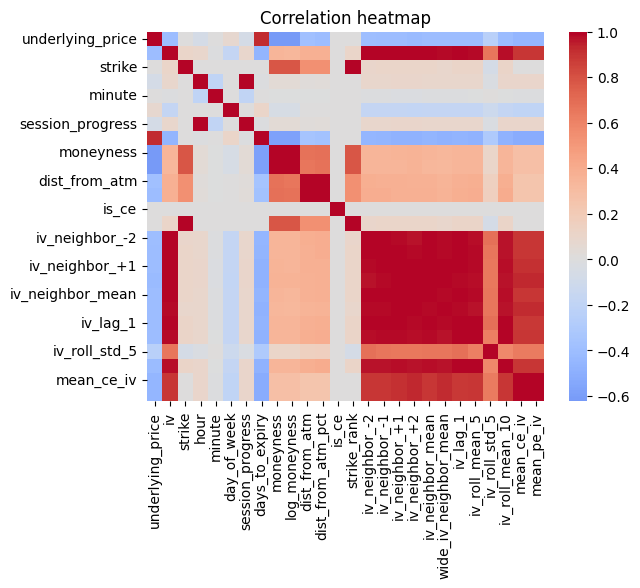

In [63]:
corr_matrix = df_long.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=False,cmap='coolwarm',center=0)

plt.title('Correlation heatmap')
plt.show()

In [64]:
corr_matrix['iv'].sort_values(ascending=True)

days_to_expiry          -4.627531e-01
underlying_price        -4.055758e-01
day_of_week             -1.749136e-01
minute                  -1.401554e-02
is_ce                   -1.672068e-16
hour                     8.966842e-02
session_progress         8.972200e-02
strike                   1.112307e-01
strike_rank              1.112307e-01
log_moneyness            3.397289e-01
moneyness                3.429334e-01
dist_from_atm            3.759008e-01
dist_from_atm_pct        3.831612e-01
iv_roll_std_5            6.592153e-01
mean_ce_iv               8.866055e-01
mean_pe_iv               8.866055e-01
iv_roll_mean_10          9.779256e-01
iv_roll_mean_5           9.835952e-01
wide_iv_neighbor_mean    9.863630e-01
iv_neighbor_-2           9.913778e-01
iv_neighbor_+2           9.913778e-01
iv_lag_1                 9.937304e-01
iv_neighbor_mean         9.970855e-01
iv_neighbor_-1           9.971310e-01
iv_neighbor_+1           9.971310e-01
iv                       1.000000e+00
Name: iv, dt

In [72]:
df_long.to_csv('../data/processed/dataset_long.csv',index=False)